# Proyecto Grafos 0

This notebook documents graph-focused model experiments and supporting analysis workflows.

This file keeps the original experimentation style and adds a small structure note for easier navigation.


In [ ]:
import torch
print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nombre GPU:", torch.cuda.get_device_name(0))


GPU disponible: True
Nombre GPU: Tesla T4


In [ ]:
!pip install --upgrade pip --quiet
!pip install torch==2.4.1 --index-url https://download.pytorch.org/whl/cu121 --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 63.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.9.0+cu126 requires torch==2.9.0, but you have torch 2.4.1+cu121 which is incompatible.
torchvision 0.24.0+cu126 requires torch==2.9.0, but you have torch 2.4.1+cu121 which is incompatible.


In [ ]:
!pip install unsloth --quiet
!pip install networkx pandas --quiet


In [ ]:
import torch
from unsloth import FastLanguageModel

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Unsloth cargó correctamente ")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
torch version: 2.9.0+cu128
cuda available: True
GPU: Tesla T4
Unsloth cargó correctamente 🚀


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import torch
from unsloth import FastLanguageModel
import networkx as nx

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

from google.colab import drive
drive.mount('/content/drive')

# Ejemplo de lectura de CSV desde Drive
# df = pd.read_csv('/content/drive/MyDrive/ruta_a_tu_archivo.csv')
# df.head()


torch version: 2.9.0+cu128
cuda available: True
GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from itertools import product


In [ ]:
model,tokenizer=FastLanguageModel.from_pretrained("Qwen/Qwen3-Embedding-4B",max_seq_length=10000,load_in_4bit=True)

==((====))==  Unsloth 2025.11.3: Fast Qwen3 patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Unsloth: Will load Qwen/Qwen3-Embedding-4B as a legacy tokenizer.


In [ ]:
formatt=lambda instruct,query:f"""Instruct:{instruct}\nCorpus:{query}"""
instruction="cuantify the  corpus attribute in a manner representative with respect to his semantic contents"
description1="""Echidna's curiosity toward the unknown and thirst for knowledge were the two things that defined her behavior. She referred to it as love and directed those feelings toward Subaru's Return by Death, which she was interested to the point that she longed to become his advisor to record the many possibilities created with Subaru’s Authority. At first glance, she was polite, soft-spoken, understanding, and even a bit childish. She was stated by the other Witches to be quite clumsy like the time when she accidentally set the forest on fire, nearly burning to death, as she was trying to warm herself.[2] She was also somewhat forgetful in regards to daily tasks. The other Witches also mentioned that she once forgot to change from her nightgown, and accidentally went out in public without properly dressing.[3]

Described as being black-hearted, she could not understand the feelings of others, and could be seen as a sociopath by normal standards. According to herself, she learned only negative emotions such as contempt and ridicule from her parents, and because she was never given a proper example of how love was meant to feel, she could not understand her own emotions of love or other such positive emotions. If it was to get a hold of more knowledge, she had no problems with employing sophistry, lying, and deceiving others. She was reasonably polite and even jovial to Subaru, whenever the two interacted. Even after the reveal that she was black hearted and after Subaru called her a monster, she kept acting like an affable individual. Though Echidna ultimately respected Subaru's decision to press on in his struggles without her help, she revoked his qualifications for entering her Castle of Dreams, as payback for not taking her hand. However, she interacted with extremely hostile will only toward three people in the world: Emilia, Satella, and one other unnamed individual. While Echidna does have some trouble with certain emotions, she isn't actually as emotionless as she made herself out to be to Subaru. It also is notable that she does maintain elements of the personality she showed Subaru even when she isn't around him. This being said, Al noticed that, despite not being able to understand the hearts of others, she was not heartless herself, as at times, he would catch glimpses of sadness, guilt, and loneliness in her.

As Echidna from four centuries ago and Echidna from the Castle of Dreams were stated to be two separate entities, the two also differ somewhat in personality. The original Echidna is much more considerate, empathetic and helpful than her counterpart from the Castle of Dreams"""
description2="""
Roswaal comes across as an eccentric due to his flamboyant appearance and odd speaking style, the latter which he shares with his grandmother. He often comes off as a friendly enough person, if weird, to speak with, usually behaving light-heartedly with the people around him. Roswaal cares about Ram and Rem a great deal and holds them in high regard among his staff. However, he is unusual among the nobility for having such close relations with demi-humans, to the point that many are hired by him, and he has come to be known as the Demi-Human Lover because of it. This has led to unsavory rumors that have suggested he has a fetish for them. That said, Garfiel speculates this is actually because he's been gathering half-bloods to the Sanctuary. He has also shown to become uncomfortable when dealing with positive talk about himself, such as when he got caught in the middle of such talk between Ram and Serena Dracroy. Despite his apparent eccentricities, as his position demands, he harbors a far more calculating, scheming reserved side with a sharp political mind and gaze that reads others quite well. He is shown to be able to manipulate others to his whims through wordplay and displays of power, and he is nigh unbendable on the political battlefield, willing to take drastic actions to get his way, such as manipulating the environment of the Royal Selection Ceremony to ensure Emilia's position as one of the candidates in spite of her appearance. He has a habit of not talking to another person without being in a superior position, intent on grasping the other party's intentions, seizing their weaknesses, and if necessary, take hostages to secure his advantage, making him a formidable negotiator as well, while simultaneously displaying his cautious, even cowardly, nature. He has also said that he believed that when a person relies on something, that they should die by what it is they rely on, whether that is the sword, magic, fire, etc.; it is because of this that he told Ram that he would allow himself to die by her hand should the future ever deviate from his Book of Wisdom's predictions as penance for allowing her village to meet its destruction for his own ends.

In Roswaal's original incarnation of Roswaal A. Mathers, he was much brighter and more prideful, and he often found himself amused during his playful interactions with Beatrice. He had been mischievous, messing with Beatrice in the same way that she would mess with Ryuzu by using his yang magic to loop a room endlessly against her, and he tended to tease her, much to her annoyance. He also held great pride in his knowledge of magic, which only increased over time. However, the part of him that most dominated his personality was his love for Echidna, his teacher. Despite his condition causing him problems with his own relatives, she was the one who not only taught him magic but even saved his life, even having gone out of her way to kiss him when they first met to relieve him of the pressure of the mana assailing his body. Because of this, he was heavily dedicated to her, and he was willing to use himself to fight for and protect her when necessary.

Following the attack on the Sanctuary by Hector and the death of Echidna, his psyche was greatly wounded. He had become more depressed and would often pore over all of the knowledge in the Forbidden Library, continue mastering magic, and research methods of revival. He believed that his purpose was to meet his teacher Echidna again at any cost, even if that meant sacrificing himself or those close to him, making Echidna from the Castle of Dreams to describe him as being "a little too earnest." This made him rely heavily on his Gospel, believing that so long as he followed it, he would one day see his teacher again. Likewise, as a result of the strong emotions engraved into him following his encounter with the Warlock of Melancholy. he started mimicking Hector's mannerisms, including his eccentric way of speaking and his clown makeup. He has stated that even without his makeup, he was a clown.

Over the centuries, Roswaal had a certain darkness to him, making it to where not only had he become entirely incapable of using healing magic, a magic he believed was a gentle type of magic, but he started to become more ruthless in his goal to revive his teacher, allowing tragedies to occur or even set them up so that his goal could be met. This has led him to ignore the Witch Cult's attack on the Oni Clan's village, waiting until only Rem and Ram remained as he need Ram in particular for his goals. Likewise, upon learning of Subaru, the other person who was required to revive his teacher, he began setting up numerous schemes in order to make Subaru a Sage and become like himself, believing he had a sort of kinship with him. This has led to him forcing his will on Subaru by hiring an assassin and summoning the Great Rabbit to kill everyone involved with Emilia just to have things go his way.

However, after his Book of Wisdom was burned during the events of the Sanctuary and having nearly killed Ram, he became lost and did not know what to do, becoming nearly despondent, even in the face of danger, with his only thought to be to infuse mana into Ram's severed horn. Following the loss of his bet with Subaru, Roswaal had an Oath Bound Curse Mark placed on himself, with the condition that, were he ever to bring harm to anyone in the camp or those Subaru cares for again, his soul would burn and never again return to Od Lagna. Likewise, after witnessing his plan fail so utterly, witnessing Ram's courage and being told of her love for him, and seeing Emilia overcome her past and trauma, something he did not believe she could overcome, something he himself could not even do, he became softer and started earnestly backing her, and he became much more lenient with the members of the Emilia Camp, often putting up with the heavy distrust of Otto Suwen, harassment from his own maid, Petra Leyte, and the somewhat mouthy Frederica Baumann. He has become much less ruthless, and he has even shown to be willing to guide those around him, such as when he provided Garfiel combat advice which allowed him to become stronger.

Despite this, he keeps his primary goal in mind, and he expects Subaru to live up to the words that he had given him about not letting anyone die or come to harm's way, threatening to force him to use his Authority should he ever make a mistake burning everything and everyone dear to Subaru. When Subaru returned from Priestella with another Witch Factor, he realized that things were still going his way when he realized that Subaru had obtained another Witch Factor, which Beatrice scolded him for. Likewise, if Subaru were to find himself in a predicament that left him separated from everybody, even if it means illegally crossing country borders, Roswaal has shown to be willing to do anything he needed to in order to retrieve him, including giving up multiple magics to compensate Clind to use his Authority.

Despite the threat that he gave to Subaru, following the events of Arc 8, he became confused in how he should be, as he was conflicted over how he and Subaru should interact regarding his own dream, Subaru’s Authority, and other such issues. Likewise, Subaru noticed that Roswaal did not decide to act on the words he’d given after the Sanctuary events, which Subaru speculated was either due to him becoming softer or because Priscilla did not count amongst those Subaru was meant to keep alive. Likewise, because he knows his own nature very well, he harbors a sense of guilt toward his comrades for keeping secrets, despite being surrounded by many kind-hearted people, which in turn compels Roswaal to deliver results with tasks they might entrust to him, as if trying to live up to his comrades' expectations. In fact, this sense is so strong that, much to his own surprise, he decided to, rather than face an opponent he should have been content with merely stalling through underhanded tricks, stand back up in spite of his own great injuries and push himself to his limits. Later, after speaking with and working alongside Ezzo Cadner, he came to the realization that he did not walk his path alone."""
description3="""
As the Sword Saint and the Knight of the Royal Guard, Reinhard acts with a high degree of chivalry and elegance, addressing everyone with an unnaturally high level of respect. He is fair, clean, brave, and willing to go out of his way in the name of justice no matter if he's in the line of duty or simply strolling through the Royal Capital. Of course, Reinhard does not believe himself worthy as the current Sword Saint, and often, rather than introducing himself as the Sword Saint, he will instead call himself a descendant of the line of Sword Saints. He is known as the Knight Amongst Knights and is widely trusted among the people of the Royal Capital of Lugunica. As a knight, Reinhard only uses his sword when necessary, since, in addition to being a rule, his iron-clad rule is to not inflict pain to others if not absolutely necessary, be it a normal thug or a member of the Witch Cult. Having said that, when Reinhard is truly needed, he swiftly deals with every threat in a matter of seconds. Most of the time, his presence and name alone are enough to send normal thugs running away.

He mentioned that his specialty is fighting monsters, but his power is so great that upon unleashing just one of his attacks, Subaru already considered him another monster. Reinhard considered this as an offensive comment, implying that he does not like being judged as someone dangerous even when he has good intentions. Despite not being fond of being referred to, with degrading titles and nicknames, Reinhard is a daily target of scorn and annoyance for his fellow members of the Felt Camp, including Felt, Ton, Chin, and Kan. Despite that, he always brushes it off with a gentle smile, which usually pisses off the group even more, subjecting the knight to even more scorn than before. Despite such unfriendly relationships, however, Reinhard is always prepared to go an extra mile and help them out when in trouble, even when they don't explicitly ask for it. As their mentor and knight, however, Reinhard can also be pretty stern. Chin, for example, will refrain from using his Fire Magic to call Reinhard as, if the Sword Saint doesn't deem the situation dire, he will not hesitate to scold him and apprehend him if necessary. This strict attitude is often aimed at his mistress as well. Reinhard expressed dissatisfaction and even anger, on multiple occasions, such as when Felt carelessly entered the room where Louanna Astrea sleeps, in the Astrea Manor located in the Royal Capital.

He is always looking for a way to solve things, even to the point of giving a Sin Archbishop the opportunity to surrender while hoping he will not have to take extreme measures, such as being forced to kill him. In his fight against Regulus Corneas, he even went as far as asking him to stop and leave the city, even after the Sin Archbishop had already killed him and decimated everything in their vicinity. He also respects the decision of his friends, despite the fact that sometimes they criticize him for engaging in matters that do not correspond to him. Due to his unparalleled strength, however, Reinhard is usually the one people turn to when trouble calls, no matter what their relationship with him is.

Although hesitant, Reinhard was willing to practice lethal force on his opponents in the event it was absolutely necessary. An example of this was when he killed the Imperial spy Miles for trying to escape the Kingdom atop a Flying Dragon after Reinhard had ordered him to disembark. On the other hand, however, he is heavily against tactics that revolve around suicidal attacks, and he will do what he can to prevent the assailants' deaths. Despite the role his paternal grandparents played in the Demi-Human War, as well as the general anti-demi-human policy employed by citizens of Lugunica, Reinhard held no discrimination against those of demi-human ancestry.

Reinhard respects the rules of duels and will usually accept them if offered, such as when Regulus offered to duel a "knight" while he was attempting to goad Subaru or when Cecilus Segmunt challenged him to a duel. However, he finds it disrespectful and insulting when such a duel is reneged upon, and in the case of criminals like Regulus, he will immediately attack in response.

As a five-year-old child, Reinhard was a very sweet and timid kid, stuttered a lot, and easily got shocked or surprised. As he deeply loved his father, he was willing to do everything in his power to help him, even going as far as obtaining a Divine Protection of Mind-Changing in order to help Heinkel convince Marcos Gildark to rejoin the Royal Knight Order; however, after the Astrea Manor was attacked by a group of men led by then-fourteen-year-old Russell Fellow, Heinkel pleaded to Reinhard to never use the Divine Protection again. Reinhard fell in a state of shock and immediately locked off and erased his newly gained Divine Protection. Considering his monstrous power, however, Reinhard, even as a child, was easily capable of sending shivers down grown and battle-hardened men's spines, by simply looking into their eyes and voicing a demand with a somewhat intimidating voice.
"""

input1=tokenizer(formatt(instruction,description1),return_tensors="pt").to(model.device)


input2=tokenizer(formatt(instruction,description2),return_tensors="pt").to(model.device)
input3=tokenizer(formatt(instruction,description3),return_tensors="pt").to(model.device)
with torch.no_grad():
 pred1=torch.nn.functional.normalize(model(**input1,output_hidden_states= True).hidden_states[-1][:,-1,:],dim=1,p=2)

 pred2=torch.nn.functional.normalize(model(**input2,output_hidden_states= True).hidden_states[-1][:,-1,:],dim=1,p=2)
 pred3=torch.nn.functional.normalize(model(**input3,output_hidden_states= True).hidden_states[-1][:,-1,:],dim=1,p=2)



In [ ]:
pred1 @ pred3.T

tensor([[0.3630]], device='cuda:0', dtype=torch.float16)

In [ ]:

def get_detailed_instruct(task_description: str, query: str) -> str:
    return f'Instruct: {task_description}\nQuery:{query}'


In [ ]:
from google.colab import files
import pandas as pd

# Subir el archivo xd (1).csv
uploaded = files.upload()  # Esto abrirá un selector de archivos

# Leer el CSV
df = pd.read_csv("xd (1).csv")
textos = [i for i in df["0"] if i != "[deleted]"]

print(f"Se cargaron {len(textos)} textos válidos")


Saving xd (1).csv to xd (1) (4).csv
Se cargaron 60 textos válidos


In [ ]:
len(textos)

60

In [ ]:
te={f"texto_{i}":j for i,j in enumerate(textos)}
grafof=nx.Graph()
for j in te:
    grafof.add_node(j)

nodes=grafof.nodes()
edges=[(a,b) for a,b in product(nodes,nodes) if a!=b]
grafof.add_edges_from(edges)


In [ ]:
!pip install pyforceatlas2

In [ ]:
from pyforceatlas2 import ForceAtlas2

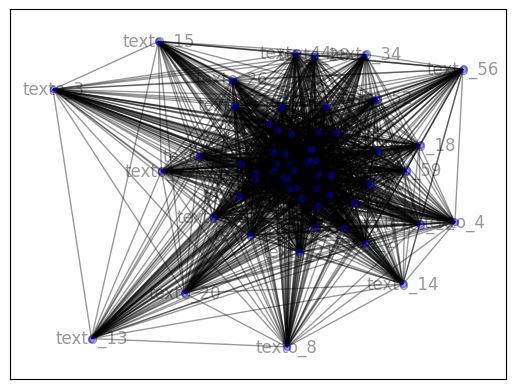

In [ ]:
nx.draw_networkx(grafof, pos, node_size=20, node_color="blue", alpha=0.4)

In [ ]:
vectors={}

for node in nx.bfs_tree(grafof,list(te.keys())[0]):
 with torch.no_grad():
    tokenization=tokenizer(formatt(instruction,te[node]),return_tensors="pt").to(model.device)
    vectors[node]=torch.nn.functional.normalize(model(**tokenization,output_hidden_states=True).hidden_states[-1][:,-1,:],p=2,dim=1).detach().cpu().to(torch.float32)
print(vectors)
values=[]
print(grafof.edges())
for edge in grafof.edges():
    values.append(1/(0.5+torch.cdist(vectors[edge[0]],vectors[edge[1]]).numpy()[0][0]))



{'texto_0': tensor([[ 0.0005,  0.0195,  0.0306,  ...,  0.0047, -0.0058,  0.0083]]), 'texto_1': tensor([[-0.0002,  0.0202,  0.0914,  ...,  0.0165,  0.0015, -0.0038]]), 'texto_2': tensor([[-0.0003,  0.0069,  0.0259,  ..., -0.0193, -0.0267,  0.0153]]), 'texto_3': tensor([[ 0.0003,  0.0259,  0.0108,  ...,  0.0095,  0.0065, -0.0011]]), 'texto_4': tensor([[ 0.0004,  0.0186, -0.0009,  ..., -0.0088, -0.0249,  0.0054]]), 'texto_5': tensor([[-0.0003,  0.0244,  0.0378,  ...,  0.0103,  0.0081, -0.0040]]), 'texto_6': tensor([[ 1.4603e-05,  1.2787e-02,  1.8997e-02,  ...,  3.8338e-03,
         -4.1229e-02, -1.9928e-02]]), 'texto_7': tensor([[ 0.0003,  0.0114, -0.0040,  ..., -0.0054, -0.0144, -0.0141]]), 'texto_8': tensor([[ 0.0002, -0.0069,  0.0092,  ..., -0.0145,  0.0043, -0.0045]]), 'texto_9': tensor([[ 0.0006,  0.0185, -0.0051,  ...,  0.0110, -0.0123, -0.0291]]), 'texto_10': tensor([[-1.3053e-05, -5.8136e-03,  6.0059e-02,  ..., -1.0345e-02,
         -2.0203e-02,  3.0346e-03]]), 'texto_11': tensor(

In [ ]:
forceatlas2 = ForceAtlas2(outbound_attraction_distribution=True,scaling_ratio=1500 )
pos = forceatlas2.forceatlas2_networkx_layout(grafof, iterations=5000)


ForceAtlas2 iterations: 100%|██████████| 5000/5000 [00:12<00:00, 407.45it/s]


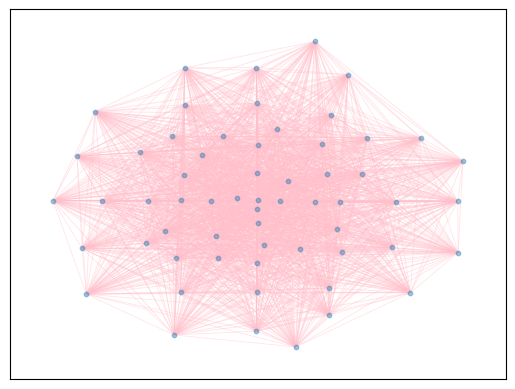

In [ ]:
nx.draw_networkx(grafof,pos,width=values,alpha=0.4,node_size=10,edge_color="black",with_labels=False)

In [ ]:
values.index(min(values))


528

In [ ]:
list(grafof.edges())[628]


('texto_11', 'texto_46')

In [ ]:
print("tuah")

tuah


In [ ]:
print(te["texto_11"])

I might be a very unusual guy. My hobbies and interests are almost limited to physics, meteorology, linguistics and flags. I do honestly don't do anything except studying. I'm fluent in few languages and I have a fair understanding of more languages.

I'm just a honest, and lonely guy who distracts himself from being lonely with studying.


In [ ]:
print(te["texto_46"])

I know it's getting real tough for you now but *60* hour work weeks AND a full time *PhD* student (in a tough field no less)? u/ProbableErorr, are you a witch?

I failed out JC while working less than part time and volunteering (weekly). Not that it matters, but you are objectively at least twice as intelligent as I am. 


&amp;nbsp;


&amp;nbsp;


I had some small trouble on how to start this. You and most people start with " I'm " and I was going to go that route but some fatigue causes me to draw a blank. Then that reminded me of [my favorite robot](https://www.youtube.com/watch?v=UoK5MIIJnZ4).


28 IT "support" guy that has dull and kind of secluded life interspersed with the only things worth doing in life (though half the time it's out of habit than actual enjoyment). In descending order of time spent: watching cartoons/anime, looking at web comics/cute animals/dark humor/(dank) memes, daydreaming, pondering aimlessly/pseudo amateur philsophizing, reading, and exercising/powerlif